In [52]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

True

In [53]:
model = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash')

In [54]:
class LLMstate(TypedDict):
    run : int
    balls : int
    fours : int
    sixes : int

    run_rate : float
    ball_per_boundary : float
    bounary_percentage : float


In [55]:
graph = StateGraph(LLMstate)

In [56]:
def calculate_run_rate(state : LLMstate)-> LLMstate:
    run_rate = state["run_rate"] = state["run"] / state["balls"]*100
    return {'run_rate' : run_rate}

In [57]:
def calculate_bpb(state: LLMstate)->LLMstate:
    bpb = state["ball_per_boundary"] = state["balls"]/(state['fours']+state['sixes'])
    return {"ball_per_boundary" : bpb}

In [58]:
def calculate_BP(state: LLMstate) -> LLMstate:
    bp = state["ball_per_boundary"] = (state['fours']+state['sixes'])/state["balls"]
    return {'bounary_percentage' : bp}

In [59]:
graph.add_node("calculate_run_rate" , calculate_run_rate)
graph.add_node("calculate_bpb" , calculate_bpb)
graph.add_node("calculate_BP" , calculate_BP)



In [60]:
graph.add_edge(START , "calculate_run_rate")
graph.add_edge(START , "calculate_bpb")
graph.add_edge(START, "calculate_BP")
graph.add_edge("calculate_run_rate" , END)
graph.add_edge("calculate_bpb" , END)
graph.add_edge("calculate_BP" , END)

workflow = graph.compile()

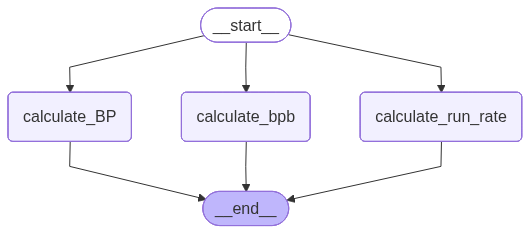

In [61]:
workflow

In [62]:
initial_state = {'run': 120 , 'balls': 39 , 'sixes': 5 , "fours" : 6 }
answer = workflow.invoke(initial_state)


In [63]:
print(answer)

{'run': 120, 'balls': 39, 'fours': 6, 'sixes': 5, 'run_rate': 307.69230769230774, 'ball_per_boundary': 3.5454545454545454, 'bounary_percentage': 0.28205128205128205}
